# Create Rays covering points in a pie

## Imports from package

In [1]:
from typing import Sequence

import numpy as np
import numpy.ma as ma
from bact_bessyii_bluesky.applib.utils.create_rays_on_grid import create_rays_on_grid
from bact_bessyii_bluesky.applib.utils.produce_in_between import produce_in_between
from bact_bessyii_bluesky.model.excitation_rays import Excitation, ExcitationRay, ExcitationCollection


In [2]:
import importlib
import  bact_bessyii_bluesky.applib.utils.create_rays_on_grid 
importlib.reload( bact_bessyii_bluesky.applib.utils.create_rays_on_grid )
from bact_bessyii_bluesky.applib.utils.create_rays_on_grid import create_rays_on_grid, create_rays_on_turned_grid

## General imports

In [3]:
import matplotlib.pyplot as plt
import jsons
import pprint

## Create the angles of the rays

In [4]:
angles = [0, 90] + [angle for angle in produce_in_between(0, 90, maxdepth=5)]
angles = np.array(angles)
angles

array([ 0.    , 90.    , 45.    , 22.5   , 67.5   , 11.25  , 56.25  ,
       33.75  , 78.75  ,  5.625 , 50.625 , 28.125 , 73.125 , 16.875 ,
       61.875 , 39.375 , 84.375 ,  2.8125, 47.8125, 25.3125, 70.3125,
       14.0625, 59.0625, 36.5625, 81.5625,  8.4375, 53.4375, 30.9375,
       75.9375, 19.6875, 64.6875, 42.1875, 87.1875])

In [5]:

def convert_complex_ray_to_excitations(ray: Sequence[complex]) -> Sequence[Excitation]:
    return [Excitation(float(p.real), float(p.imag)) for p in ray]


def convert_complex_rays_to_excitation_rays(rays: Sequence[Sequence[complex]]) -> Sequence[ExcitationRay]:
    return [ExcitationRay(ray=convert_complex_ray_to_excitations(ray)) for ray in rays]


## Input data

In [35]:
x = np.concatenate([np.linspace(0, 3, 3*2, endpoint=False), np.linspace(3, 5, 2* 4 + 1 )])
y = np.concatenate([np.linspace(0, 3, 3*2, endpoint=False), np.linspace(3, 5, 2* 4 + 1)])
X, Y  = np.meshgrid(x,y)
Z_grid = X + Y * 1j
radius = 4.5
mask = np.abs(Z_grid) > radius
Zm = ma.masked_array(Z_grid, mask=mask)

r = np.linspace(0, 5, num=101)


In [36]:
x, y

(array([0.  , 0.5 , 1.  , 1.5 , 2.  , 2.5 , 3.  , 3.25, 3.5 , 3.75, 4.  ,
        4.25, 4.5 , 4.75, 5.  ]),
 array([0.  , 0.5 , 1.  , 1.5 , 2.  , 2.5 , 3.  , 3.25, 3.5 , 3.75, 4.  ,
        4.25, 4.5 , 4.75, 5.  ]))

## Overview plots

### Input data 

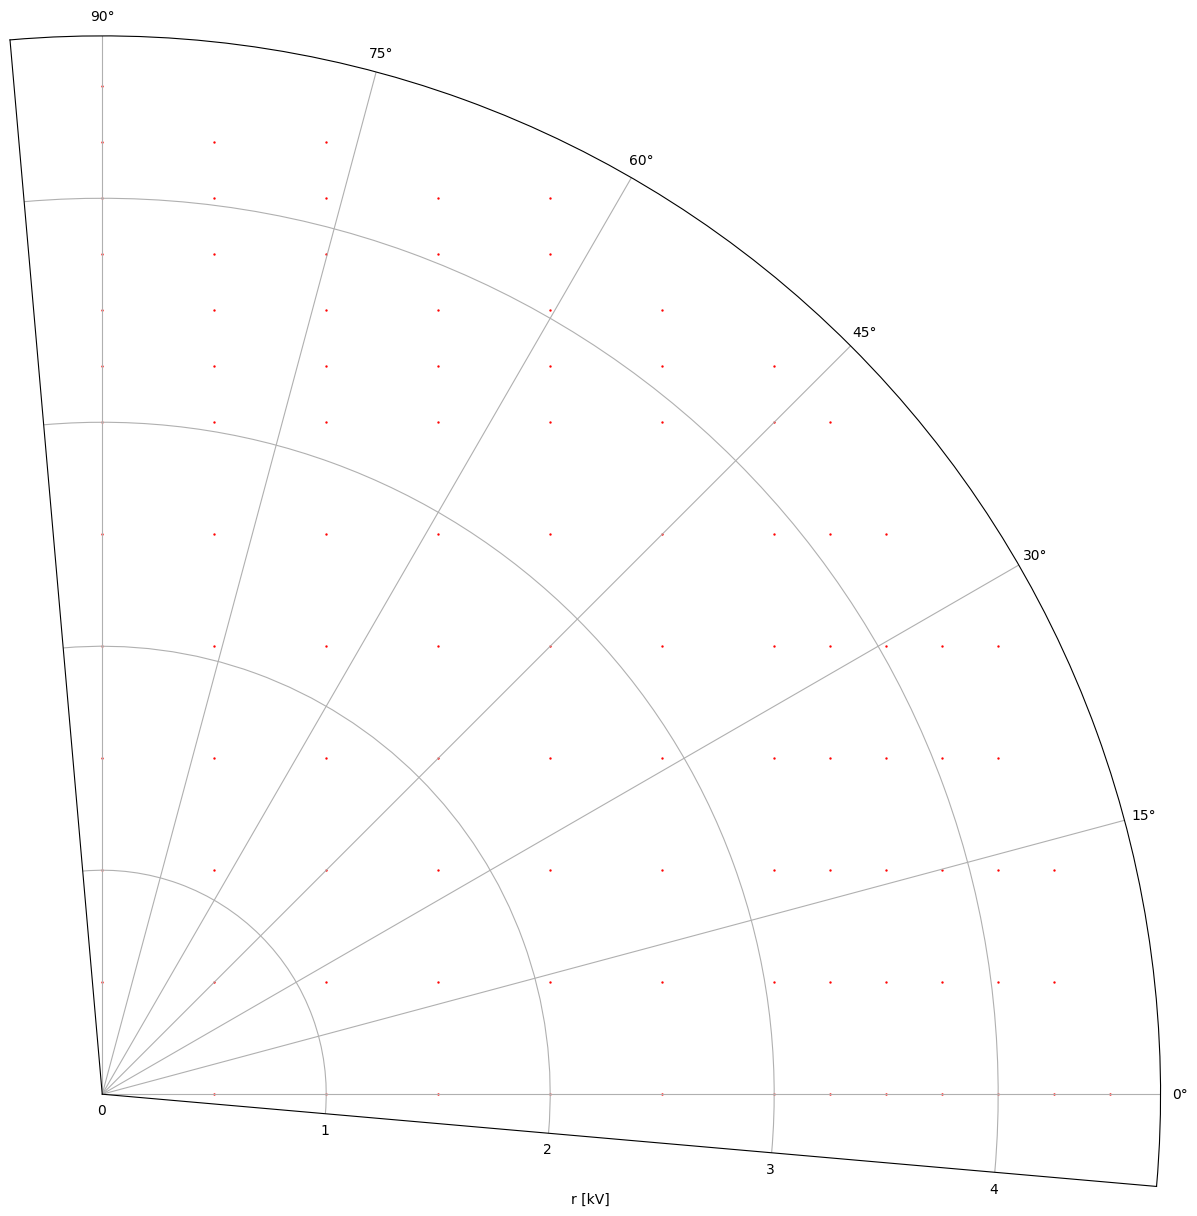

In [37]:
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': 'polar'}, figsize=[16, 16])
ax.clear()
ax.set_thetamin(-5)
ax.set_thetamax(95)
ax.scatter(np.angle(Zm).ravel(), np.absolute(Zm).ravel(), s=.5, color='r')
ax.set_xlabel('r [kV]')

fig.subplots_adjust(bottom=0.1, right=0.85, top=0.9)

## Output data

In [45]:
rays, covered_points = create_rays_on_turned_grid(
    Zm, angles/180.0*np.pi, r, threshold=0.25
)
rays = [ray for ray in rays if len(ray)]
ec = ExcitationCollection(col=convert_complex_rays_to_excitation_rays(rays))
len(rays), len(ec.col)

(17, 17)

### the rays

In [46]:
#pprint.pprint(rays)

### Plot the rays

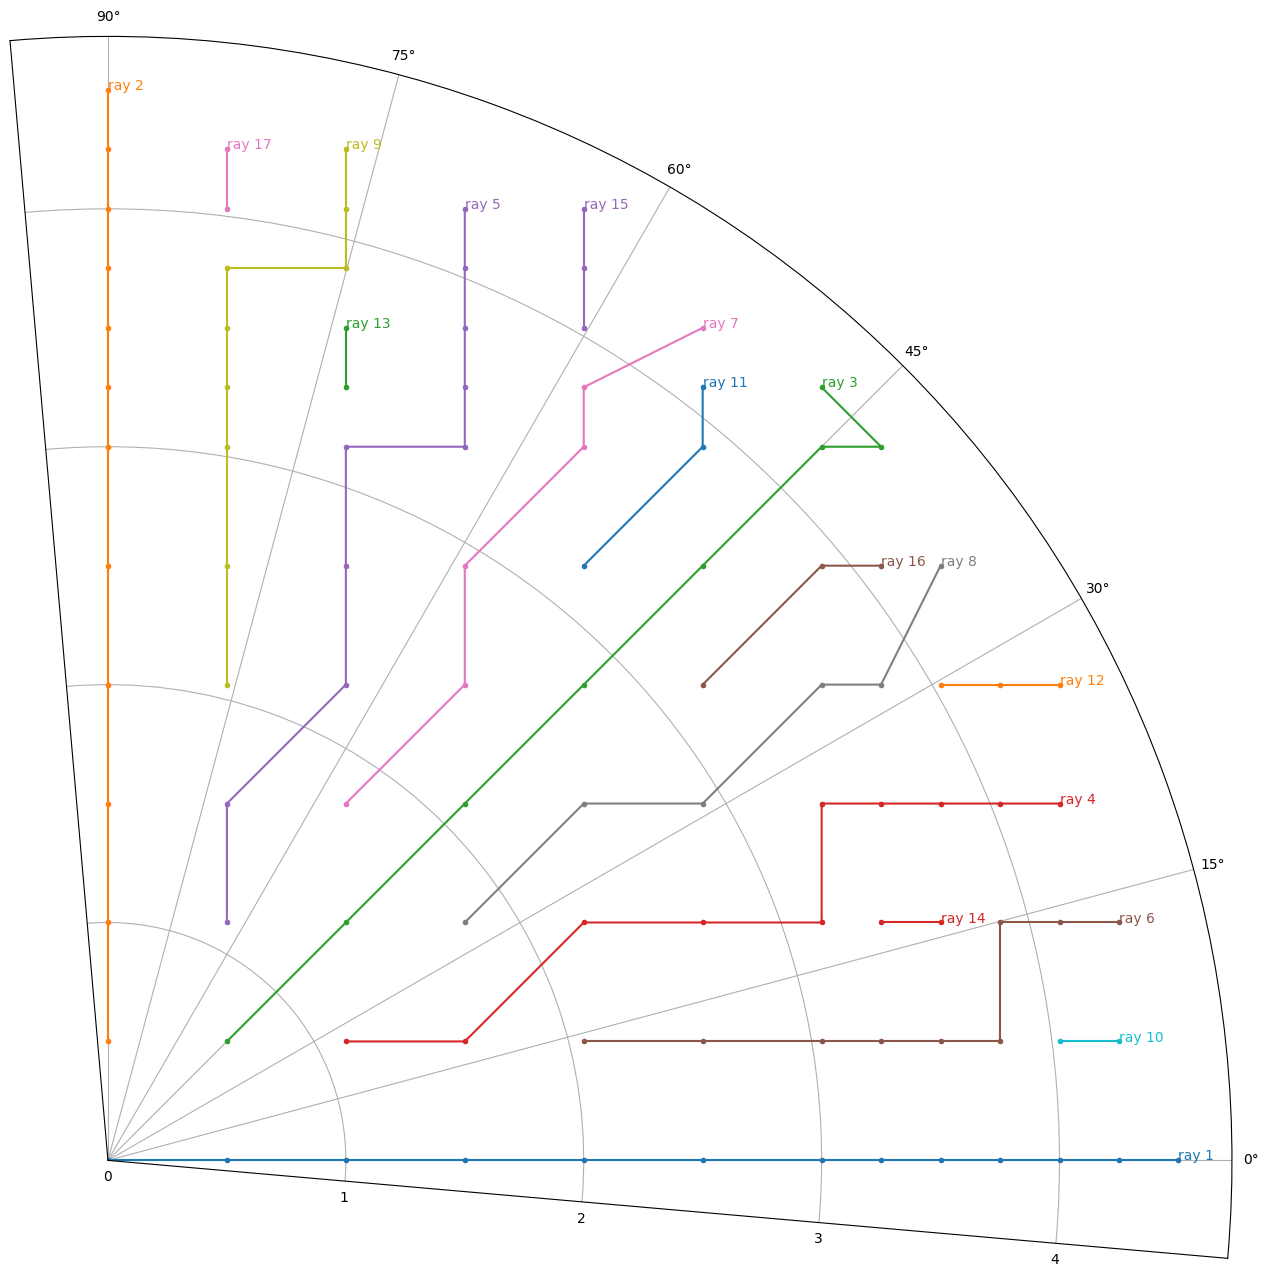

In [48]:
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': 'polar'}, figsize=[16, 16])
ax.clear()
ax.set_thetamin(-5)
ax.set_thetamax(95)
ax.scatter(np.angle(Zm).ravel(), np.absolute(Zm).ravel(), s=6, color='r')

def ray_to_phi_radius(ray: Sequence[Excitation]):
    Z = np.array([e.horizontal + e.vertical * 1j for e in ray])
    return np.angle(Z), np.absolute(Z)

for cnt, ray in enumerate(ec.col):
    points = ray_to_phi_radius(ray.ray)
    line, = ax.plot(*points, marker='.', linestyle='-')
    ax.text(points[0][-1], points[1][-1], f"ray {cnt+1}", color=line.get_color())


### The remaining points

In [28]:
covered_points
Z_remaining = ma.masked_array(Z_grid, mask=covered_points)

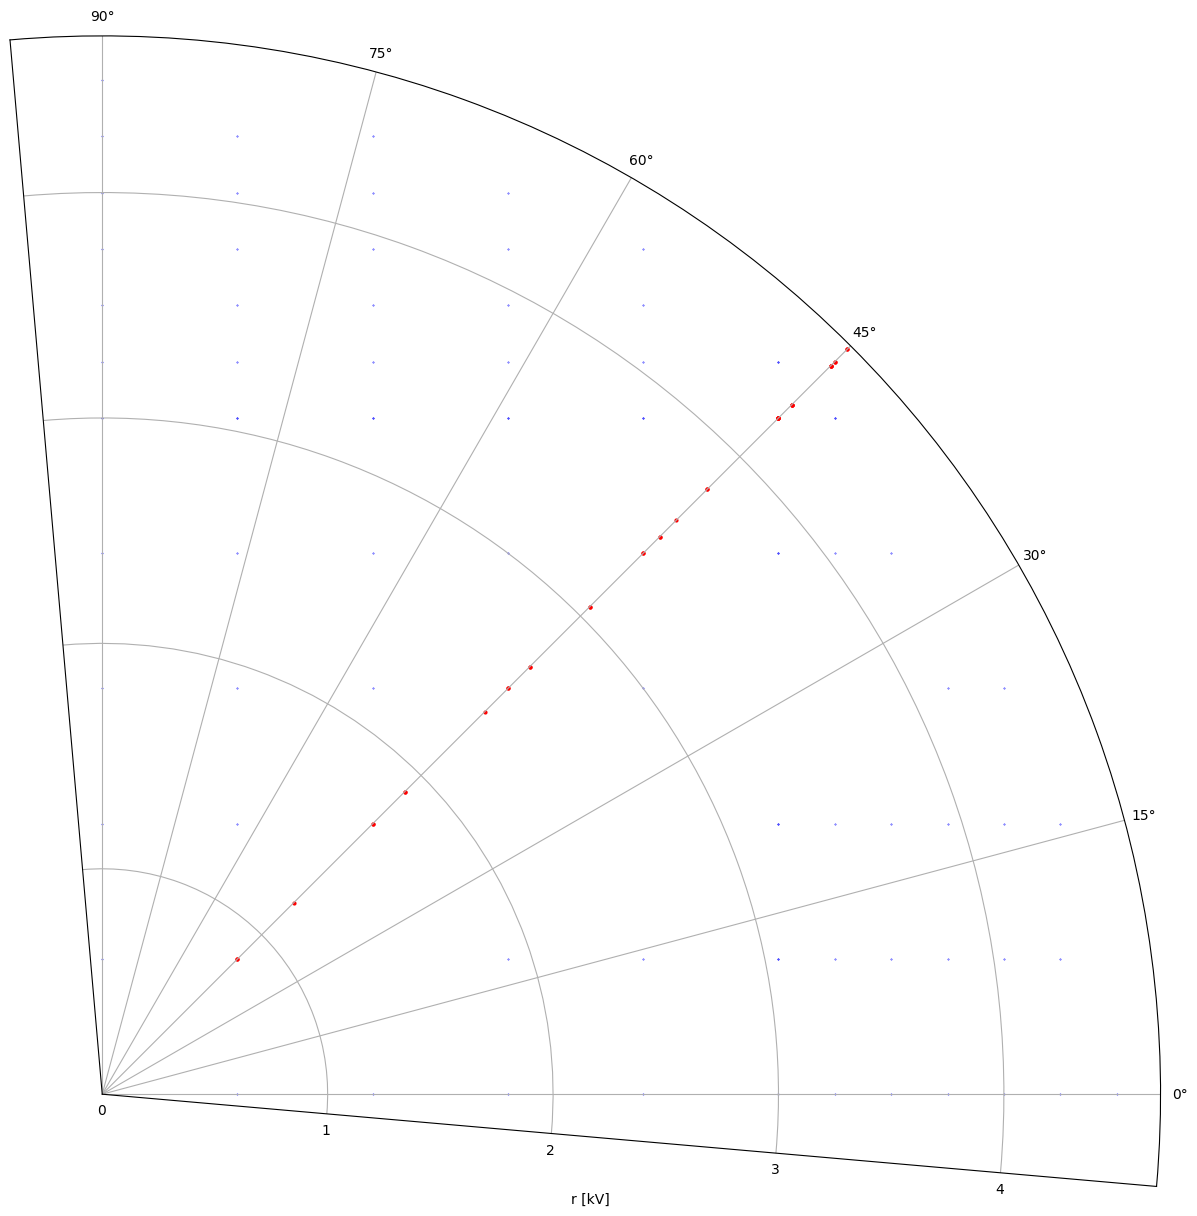

In [29]:
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': 'polar'}, figsize=[16, 16])
ax.clear()
ax.set_thetamin(-5)
ax.set_thetamax(95)
ax.scatter(np.angle(Zm).ravel(), np.absolute(Zm).ravel(), s=.1, color='b')
ax.scatter(np.angle(Z_remaining).ravel(), np.absolute(Z_remaining).ravel(), s=4, color='r')
# ax.scatter(Phi_rays.ravel(), R_rays.ravel(), s=2, color='k')

ax.set_xlabel('r [kV]')
# ax.set_rmax(1)
fig.subplots_adjust(bottom=0.1, right=0.85, top=0.9)

In [30]:
n_max = len(x)
threshold=0.05

In [31]:
angle = 45

Z_rot = Z_grid * np.exp(1j * -angle/180*np.pi)

dZ = np.absolute(Z_rot.imag)
dZr = dZ.ravel()

args = dZr.argsort()
max_points = max(np.sum(dZr < threshold), n_max)
args = args[:max_points]

points = Z_rot.ravel()[args]

Zsel = Z_grid.ravel()[args]
args, points, Zsel

Zsel = Zsel.tolist()
Zsel = [z for z in Zsel if z is not None]
Zsel.sort(key=np.absolute)

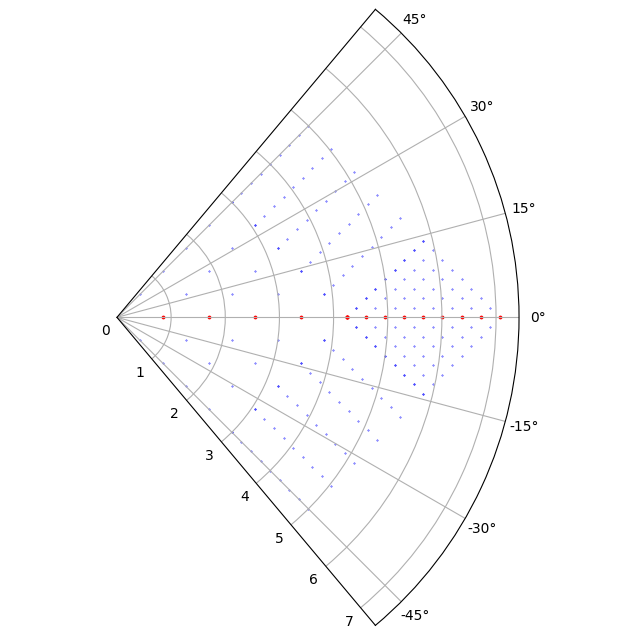

In [32]:
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': 'polar'}, figsize=[8, 8])
ax.clear()
ax.set_thetamin(-5 -angle)
ax.set_thetamax(95 - angle)
ax.scatter(np.angle(Z_rot).ravel(), np.absolute(Z_rot).ravel(), s=.1, color='b')
ax.scatter(np.angle(points), np.absolute(points), s=3, color='r', linestyle='-')


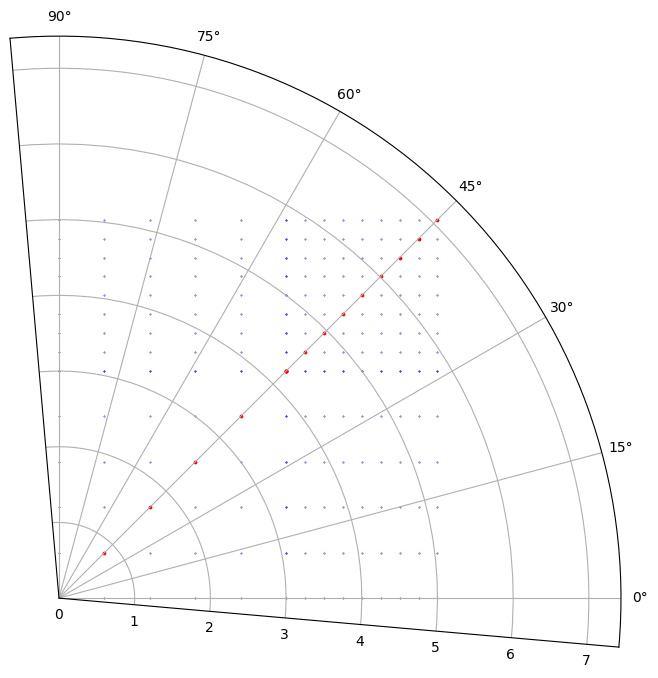

In [33]:
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': 'polar'}, figsize=[8, 8])
ax.clear()
ax.set_thetamin(-5)
ax.set_thetamax(95)
ax.scatter(np.angle(Z_grid).ravel(), np.absolute(Z_grid).ravel(), s=.1, color='b')
ax.scatter(np.angle(Zsel), np.absolute(Zsel), s=3, color='r', linestyle='-')


In [34]:
maskr = mask.ravel()
maskr[args] = True
mask = maskr.reshape(mask.shape)